# 01 - Exploratory Data Analysis

**Project:** Fraud Detection System using Big Data Analytics  
**Dataset:** Kaggle - Credit Card Transactions Fraud Detection  
**Target:** `is_fraud` (`0` = giao dịch hợp lệ, `1` = giao dịch gian lận)

Notebook này dùng để hiểu cấu trúc dữ liệu, mức độ mất cân bằng lớp, các mẫu giao dịch theo số tiền, category, merchant, thời gian, địa lý và một số đặc trưng có thể dùng cho bước preprocessing/modeling.


## 1. Setup

Notebook tự dò thư mục gốc dự án dựa trên vị trí file hiện tại. Nếu chạy notebook từ Jupyter mà `__file__` không tồn tại, code sẽ thử dùng current working directory và parent directory.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = cwd if (cwd / "data" / "raw").exists() else cwd.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"
TABLE_DIR = REPORT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = RAW_DIR / "fraudTrain.csv"
TEST_PATH = RAW_DIR / "fraudTest.csv"

print("Project root:", PROJECT_ROOT)
print("Train exists:", TRAIN_PATH.exists(), TRAIN_PATH)
print("Test exists:", TEST_PATH.exists(), TEST_PATH)

Project root: D:\main\Full\documents\uni\Nam 2\Ky 2\big data\cki\fraud-detection-bigdata
Train exists: True D:\main\Full\documents\uni\Nam 2\Ky 2\big data\cki\fraud-detection-bigdata\data\raw\fraudTrain.csv
Test exists: True D:\main\Full\documents\uni\Nam 2\Ky 2\big data\cki\fraud-detection-bigdata\data\raw\fraudTest.csv


## 2. Load Data

Dữ liệu có một cột index thừa ở đầu file CSV, vì vậy dùng `index_col=0` khi đọc để tránh tạo feature không cần thiết.


In [2]:
date_cols = ["trans_date_trans_time", "dob"]

df_train = pd.read_csv(TRAIN_PATH, index_col=0, parse_dates=date_cols)
df_test = pd.read_csv(TEST_PATH, index_col=0, parse_dates=date_cols)

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)
df_train.head()

Train shape: (1296675, 22)
Test shape: (555719, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0


In [3]:
df_train.tail()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.5600,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.8413,-111.6908,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.7000,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.9069,-78.2465,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.9300,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.6195,-105.1305,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.9000,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.7889,-103.2412,0
1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.3000,Jeffrey,Smith,M,135 Joseph Mountains,Sula,MT,59871,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.5660,-114.1861,0


## 3. Dataset Overview

Kiểm tra schema, kiểu dữ liệu, số dòng/cột và thống kê mô tả ban đầu.


In [4]:
overview = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(df_train), len(df_test)],
    "columns": [df_train.shape[1], df_test.shape[1]],
    "memory_mb": [df_train.memory_usage(deep=True).sum() / 1024**2,
                  df_test.memory_usage(deep=True).sum() / 1024**2],
})
overview

,dataset,rows,columns,memory_mb
0,train,1296675,22,986.7603
1,test,555719,22,422.9102


In [5]:
dtype_summary = (
    df_train.dtypes.astype(str)
    .value_counts()
    .rename_axis("dtype")
    .reset_index(name="column_count")
)
dtype_summary

,dtype,column_count
0,str,10
1,int64,5
2,float64,5
3,datetime64[us],2


In [6]:
pd.DataFrame({
    "column": df_train.columns,
    "dtype": df_train.dtypes.astype(str).values,
    "n_unique": df_train.nunique(dropna=True).values,
    "sample_value": [df_train[col].dropna().iloc[0] if df_train[col].notna().any() else np.nan for col in df_train.columns]
})

,column,dtype,n_unique,sample_value
0,trans_date_trans_time,datetime64[us],1274791,2019-01-01 00:00:18
1,cc_num,int64,983,2703186189652095
2,merchant,str,693,"fraud_Rippin, Kub and Mann"
3,category,str,14,misc_net
4,amt,float64,52928,4.9700
5,first,str,352,Jennifer
6,last,str,481,Banks
7,gender,str,2,F
8,street,str,983,561 Perry Cove
9,city,str,894,Moravian Falls


In [7]:
numeric_cols = df_train.select_dtypes(include=["number"]).columns.tolist()
df_train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
cc_num,"1,296,675.0000","417,192,042,079,726,656.0000","1,308,806,447,000,240,384.0000","60,416,207,185.0000","180,042,946,491,150.0000","3,521,417,320,836,166.0000","4,642,255,475,285,942.0000","4,992,346,398,065,154,048.0000"
amt,"1,296,675.0000",70.3510,160.3160,1.0000,9.6500,47.5200,83.1400,"28,948.9000"
zip,"1,296,675.0000","48,800.6711","26,893.2225","1,257.0000","26,237.0000","48,174.0000","72,042.0000","99,783.0000"
lat,"1,296,675.0000",38.5376,5.0758,20.0271,34.6205,39.3543,41.9404,66.6933
long,"1,296,675.0000",-90.2263,13.7591,-165.6723,-96.7980,-87.4769,-80.1580,-67.9503
city_pop,"1,296,675.0000","88,824.4406","301,956.3607",23.0000,743.0000,"2,456.0000","20,328.0000","2,906,700.0000"
unix_time,"1,296,675.0000","1,349,243,636.7261","12,841,278.4234","1,325,376,018.0000","1,338,750,742.5000","1,349,249,747.0000","1,359,385,375.5000","1,371,816,817.0000"
merch_lat,"1,296,675.0000",38.5373,5.1098,19.0278,34.7336,39.3657,41.9572,67.5103
merch_long,"1,296,675.0000",-90.2265,13.7711,-166.6712,-96.8973,-87.4384,-80.2368,-66.9509
is_fraud,"1,296,675.0000",0.0058,0.0759,0.0000,0.0000,0.0000,0.0000,1.0000


## 4. Missing Values and Duplicates

Dataset này thường rất sạch, nhưng vẫn cần kiểm tra để báo cáo tiền xử lý rõ ràng.


In [8]:
missing = pd.DataFrame({
    "missing_count": df_train.isna().sum(),
    "missing_percent": df_train.isna().mean() * 100,
}).sort_values("missing_count", ascending=False)

missing[missing["missing_count"] > 0]

,missing_count,missing_percent


In [9]:
print("Train duplicate rows:", df_train.duplicated().sum())
print("Test duplicate rows:", df_test.duplicated().sum())
print("Duplicate transaction IDs in train:", df_train["trans_num"].duplicated().sum())
print("Duplicate transaction IDs in test:", df_test["trans_num"].duplicated().sum())

Train duplicate rows: 0


Test duplicate rows: 0


Duplicate transaction IDs in train: 0
Duplicate transaction IDs in test: 0


## 5. Target Distribution

Fraud detection là bài toán mất cân bằng lớp mạnh. Accuracy thường gây hiểu nhầm, nên các bước modeling cần ưu tiên Precision, Recall, F1-score, ROC-AUC và có thể thêm PR-AUC.


In [10]:
def target_distribution(df, name):
    counts = df["is_fraud"].value_counts().sort_index()
    result = pd.DataFrame({
        "dataset": name,
        "is_fraud": counts.index,
        "count": counts.values,
        "percent": (counts.values / len(df)) * 100,
    })
    return result

target_dist = pd.concat([
    target_distribution(df_train, "train"),
    target_distribution(df_test, "test"),
], ignore_index=True)

target_dist.to_csv(TABLE_DIR / "target_distribution.csv", index=False)
target_dist

,dataset,is_fraud,count,percent
0,train,0,1289169,99.4211
1,train,1,7506,0.5789
2,test,0,553574,99.6140
3,test,1,2145,0.3860


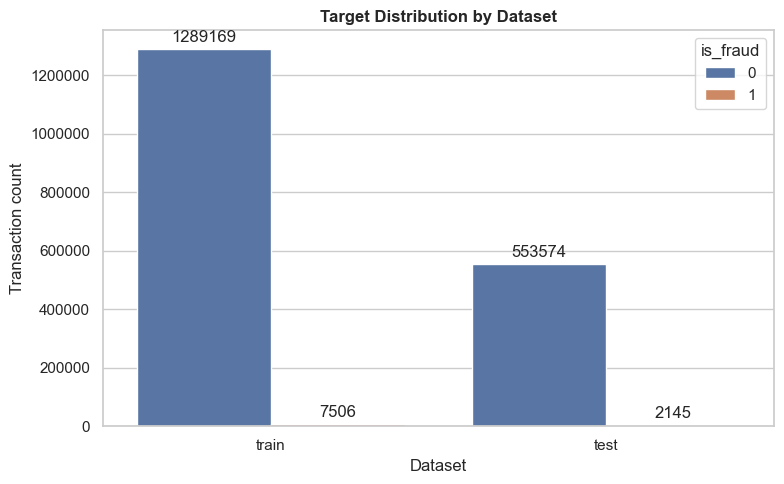

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=target_dist, x="dataset", y="count", hue="is_fraud", ax=ax)
ax.set_title("Target Distribution by Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Transaction count")
ax.ticklabel_format(style="plain", axis="y")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "target_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Transaction Amount Analysis

Số tiền giao dịch (`amt`) là feature quan trọng. Phân phối thường lệch phải rất mạnh, nên biểu đồ dùng cả dạng log scale và boxplot đã cắt ở percentile 99 để nhìn rõ phần lớn dữ liệu.


In [12]:
amount_summary = df_train.groupby("is_fraud")["amt"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    min="min",
    q25=lambda s: s.quantile(0.25),
    q75=lambda s: s.quantile(0.75),
    q95=lambda s: s.quantile(0.95),
    q99=lambda s: s.quantile(0.99),
    max="max",
).reset_index()
amount_summary.to_csv(TABLE_DIR / "amount_summary_by_target.csv", index=False)
amount_summary

,is_fraud,count,mean,median,std,min,q25,q75,q95,q99,max
0,0,1289169,67.6671,47.2800,154.0080,1.0000,9.6100,82.5400,189.9000,486.3032,"28,948.9000"
1,1,7506,531.3201,396.5050,390.5601,1.0600,245.6625,900.8750,"1,083.9850","1,179.6900","1,376.0400"


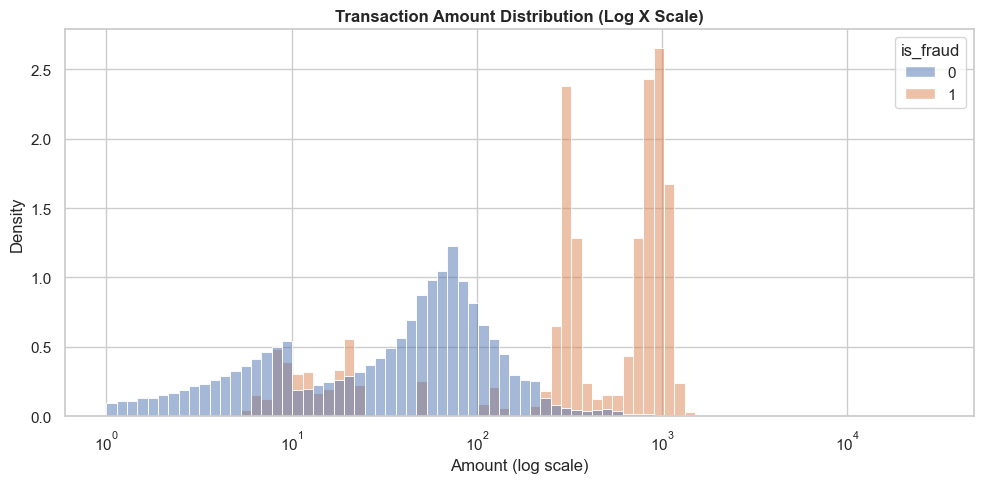

In [13]:
plot_sample = df_train.sample(n=min(200_000, len(df_train)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=plot_sample, x="amt", hue="is_fraud", bins=80, log_scale=(True, False), common_norm=False, stat="density", ax=ax)
ax.set_title("Transaction Amount Distribution (Log X Scale)")
ax.set_xlabel("Amount (log scale)")
ax.set_ylabel("Density")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "amount_distribution_log_scale.png", dpi=160, bbox_inches="tight")
plt.show()

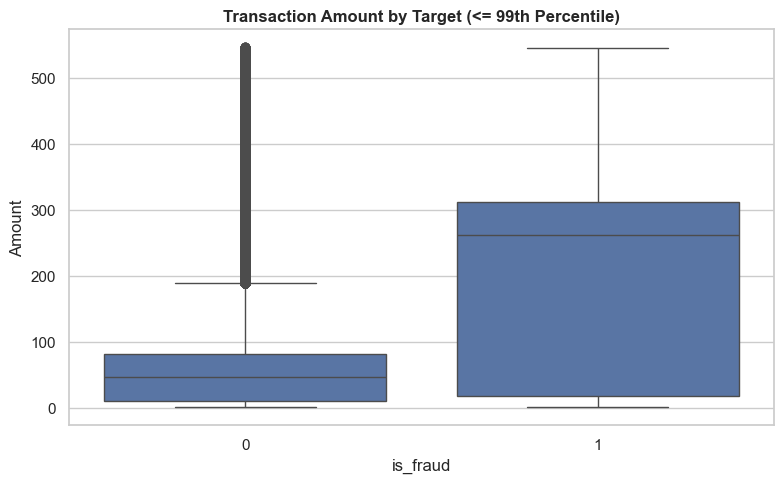

In [14]:
amount_cap = df_train["amt"].quantile(0.99)
box_data = df_train.loc[df_train["amt"] <= amount_cap, ["amt", "is_fraud"]]

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=box_data, x="is_fraud", y="amt", ax=ax)
ax.set_title("Transaction Amount by Target (<= 99th Percentile)")
ax.set_xlabel("is_fraud")
ax.set_ylabel("Amount")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "amount_boxplot_by_target.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Category Analysis

Phân tích số lượng giao dịch và tỷ lệ fraud theo `category`. Đây là feature phân loại quan trọng cho model.


In [15]:
category_stats = (
    df_train.groupby("category")
    .agg(
        transactions=("is_fraud", "size"),
        fraud_count=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean"),
        avg_amount=("amt", "mean"),
        median_amount=("amt", "median"),
    )
    .assign(fraud_rate_percent=lambda x: x["fraud_rate"] * 100)
    .sort_values("transactions", ascending=False)
    .reset_index()
)
category_stats.to_csv(TABLE_DIR / "category_fraud_stats.csv", index=False)
category_stats

,category,transactions,fraud_count,fraud_rate,avg_amount,median_amount,fraud_rate_percent
0,gas_transport,131659,618,0.0047,63.4346,62.8400,0.4694
1,grocery_pos,123638,1743,0.0141,116.9610,105.1200,1.4098
2,home,123115,198,0.0016,58.2701,48.2900,0.1608
3,shopping_pos,116672,843,0.0072,79.7792,7.7600,0.7225
4,kids_pets,113035,239,0.0021,57.5369,47.1800,0.2114
5,shopping_net,97543,1713,0.0176,88.4241,8.4400,1.7561
6,entertainment,94014,233,0.0025,64.2104,50.7400,0.2478
7,food_dining,91461,151,0.0017,51.0869,42.0300,0.1651
8,personal_care,90758,220,0.0024,47.9677,32.5850,0.2424
9,health_fitness,85879,133,0.0015,54.1821,42.8500,0.1549


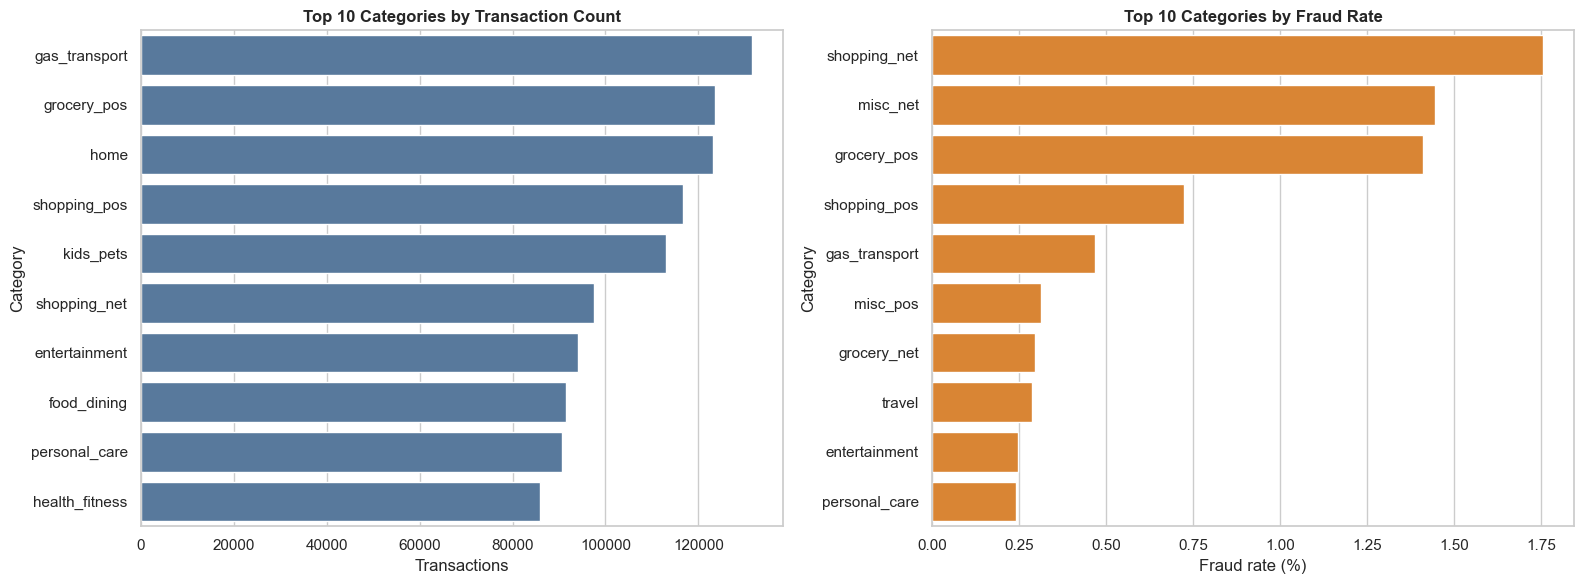

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_category_count = category_stats.sort_values("transactions", ascending=False).head(10)
sns.barplot(data=top_category_count, y="category", x="transactions", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 10 Categories by Transaction Count")
axes[0].set_xlabel("Transactions")
axes[0].set_ylabel("Category")

category_rate = category_stats.sort_values("fraud_rate_percent", ascending=False).head(10)
sns.barplot(data=category_rate, y="category", x="fraud_rate_percent", ax=axes[1], color="#F58518")
axes[1].set_title("Top 10 Categories by Fraud Rate")
axes[1].set_xlabel("Fraud rate (%)")
axes[1].set_ylabel("Category")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "category_transaction_count_and_fraud_rate.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. Merchant Analysis

`merchant` có cardinality cao. Trong modeling, cần cân nhắc encoding phù hợp hoặc tạo aggregate features như merchant fraud rate/frequency trên train set.


In [17]:
merchant_stats = (
    df_train.groupby("merchant")
    .agg(
        transactions=("is_fraud", "size"),
        fraud_count=("is_fraud", "sum"),
        fraud_rate=("is_fraud", "mean"),
        avg_amount=("amt", "mean"),
    )
    .assign(fraud_rate_percent=lambda x: x["fraud_rate"] * 100)
    .sort_values(["fraud_count", "transactions"], ascending=False)
    .reset_index()
)
merchant_stats.to_csv(TABLE_DIR / "merchant_fraud_stats.csv", index=False)
merchant_stats.head(20)

,merchant,transactions,fraud_count,fraud_rate,avg_amount,fraud_rate_percent
0,fraud_Rau and Sons,2490,49,0.0197,119.8212,1.9679
1,fraud_Cormier LLC,3649,48,0.0132,72.6582,1.3154
2,fraud_Kozey-Boehm,1866,48,0.0257,98.2381,2.5723
3,fraud_Kilback LLC,4403,47,0.0107,88.8208,1.0675
4,fraud_Doyle Ltd,2558,47,0.0184,117.6589,1.8374
5,fraud_Vandervort-Funk,2474,47,0.0190,118.2470,1.8998
6,fraud_Kuhn LLC,3510,44,0.0125,80.4009,1.2536
7,fraud_Padberg-Welch,2424,44,0.0182,115.4191,1.8152
8,fraud_Terry-Huel,1996,43,0.0215,93.2821,2.1543
9,fraud_Koepp-Witting,2437,42,0.0172,116.9344,1.7234


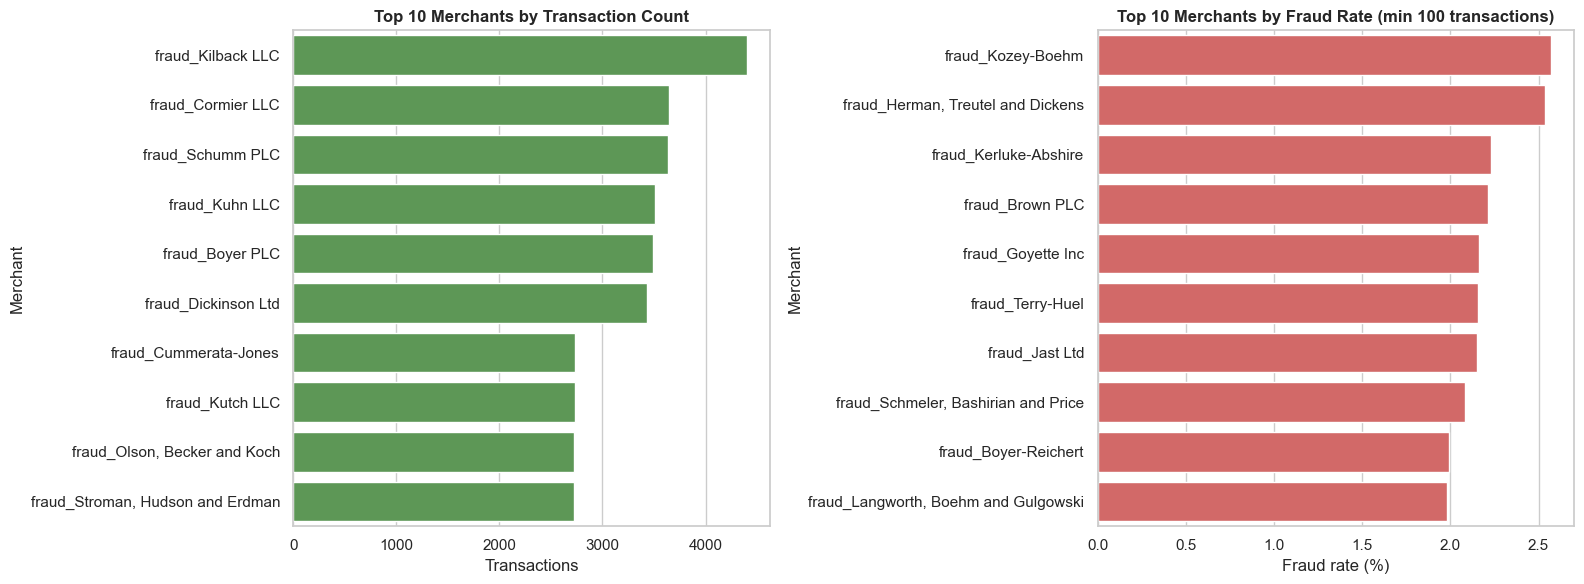

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_merchants = merchant_stats.sort_values("transactions", ascending=False).head(10)
sns.barplot(data=top_merchants, y="merchant", x="transactions", ax=axes[0], color="#54A24B")
axes[0].set_title("Top 10 Merchants by Transaction Count")
axes[0].set_xlabel("Transactions")
axes[0].set_ylabel("Merchant")

high_risk_merchants = merchant_stats.query("transactions >= 100").sort_values("fraud_rate_percent", ascending=False).head(10)
sns.barplot(data=high_risk_merchants, y="merchant", x="fraud_rate_percent", ax=axes[1], color="#E45756")
axes[1].set_title("Top 10 Merchants by Fraud Rate (min 100 transactions)")
axes[1].set_xlabel("Fraud rate (%)")
axes[1].set_ylabel("Merchant")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "merchant_transaction_count_and_fraud_rate.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Time-Based Analysis

Từ `trans_date_trans_time`, tạo các biến phân tích: giờ, ngày trong tuần, tháng, cuối tuần. Các biến này sẽ được dùng lại ở preprocessing/feature engineering.


In [19]:
eda_df = df_train.copy()
eda_df["transaction_hour"] = eda_df["trans_date_trans_time"].dt.hour
eda_df["transaction_dayofweek"] = eda_df["trans_date_trans_time"].dt.dayofweek
eda_df["transaction_day_name"] = eda_df["trans_date_trans_time"].dt.day_name()
eda_df["transaction_month"] = eda_df["trans_date_trans_time"].dt.month
eda_df["transaction_date"] = eda_df["trans_date_trans_time"].dt.date
eda_df["weekend_flag"] = eda_df["transaction_dayofweek"].isin([5, 6]).astype(int)

print("Date range:", eda_df["trans_date_trans_time"].min(), "to", eda_df["trans_date_trans_time"].max())
eda_df[["trans_date_trans_time", "transaction_hour", "transaction_day_name", "transaction_month", "weekend_flag"]].head()

Date range: 2019-01-01 00:00:18 to 2020-06-21 12:13:37


,trans_date_trans_time,transaction_hour,transaction_day_name,transaction_month,weekend_flag
0,2019-01-01 00:00:18,0,Tuesday,1,0
1,2019-01-01 00:00:44,0,Tuesday,1,0
2,2019-01-01 00:00:51,0,Tuesday,1,0
3,2019-01-01 00:01:16,0,Tuesday,1,0
4,2019-01-01 00:03:06,0,Tuesday,1,0


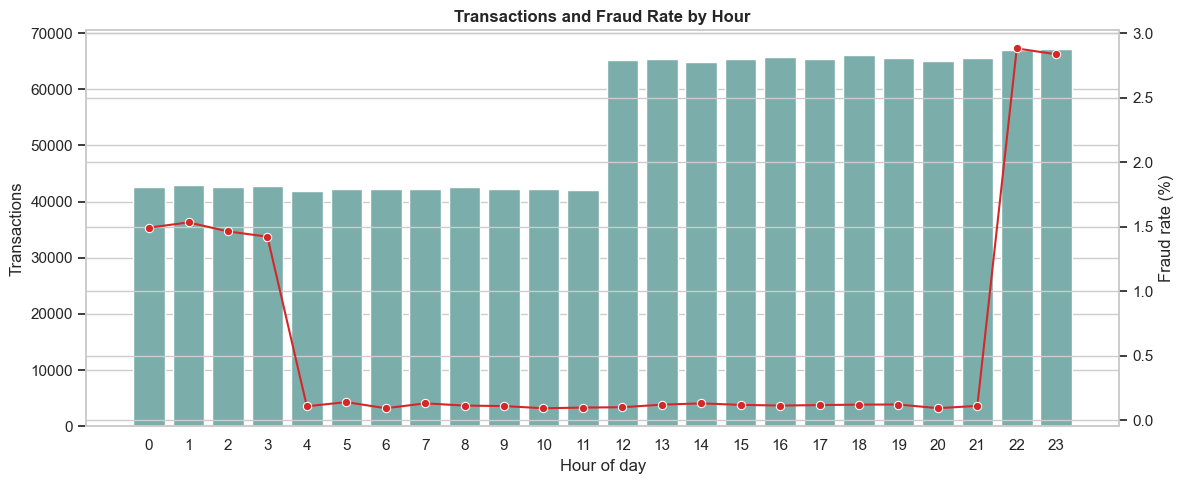

,transaction_hour,transactions,fraud_rate,fraud_count,fraud_rate_percent
0,0,42502,0.0149,635,1.4940
1,1,42869,0.0153,658,1.5349
2,2,42656,0.0147,625,1.4652
3,3,42769,0.0142,609,1.4239
4,4,41863,0.0011,46,0.1099
5,5,42171,0.0014,60,0.1423
6,6,42300,0.0009,40,0.0946
7,7,42203,0.0013,56,0.1327
8,8,42505,0.0012,49,0.1153
9,9,42185,0.0011,47,0.1114


In [20]:
hourly_stats = (
    eda_df.groupby("transaction_hour")
    .agg(transactions=("is_fraud", "size"), fraud_rate=("is_fraud", "mean"), fraud_count=("is_fraud", "sum"))
    .assign(fraud_rate_percent=lambda x: x["fraud_rate"] * 100)
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(12, 5))
sns.barplot(data=hourly_stats, x="transaction_hour", y="transactions", ax=ax1, color="#72B7B2")
ax1.set_title("Transactions and Fraud Rate by Hour")
ax1.set_xlabel("Hour of day")
ax1.set_ylabel("Transactions")
ax1.ticklabel_format(style="plain", axis="y")

ax2 = ax1.twinx()
sns.lineplot(data=hourly_stats, x="transaction_hour", y="fraud_rate_percent", ax=ax2, color="#D62728", marker="o")
ax2.set_ylabel("Fraud rate (%)")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fraud_rate_by_hour.png", dpi=160, bbox_inches="tight")
plt.show()

hourly_stats

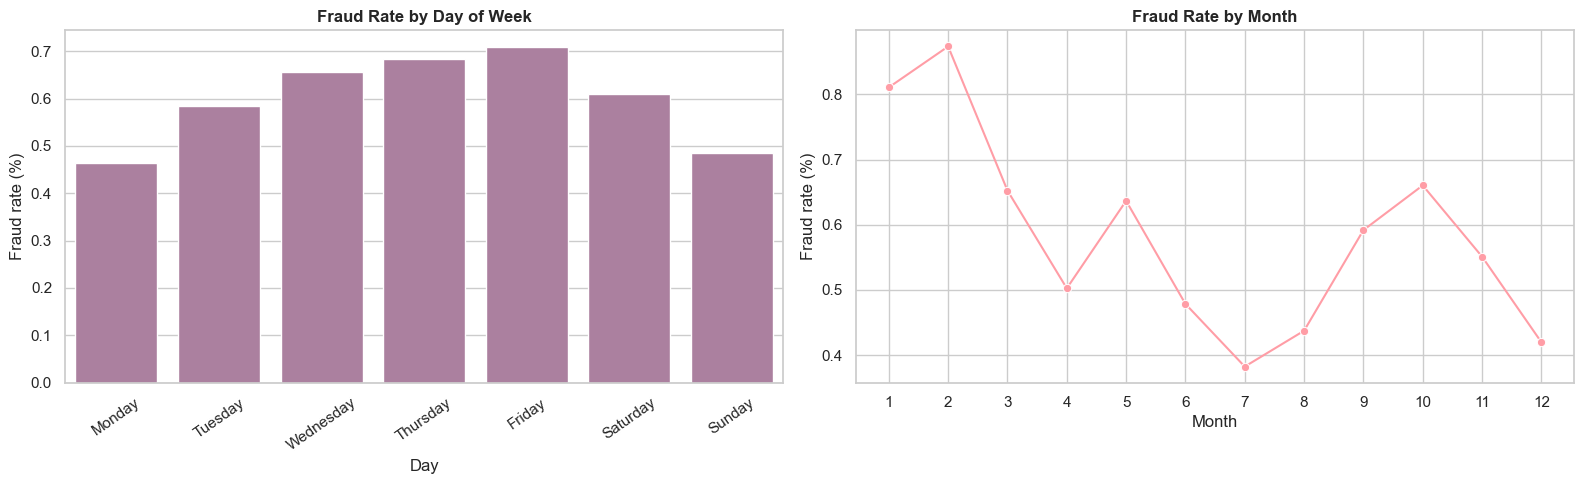

In [21]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_stats = (
    eda_df.groupby("transaction_day_name")
    .agg(transactions=("is_fraud", "size"), fraud_count=("is_fraud", "sum"), fraud_rate=("is_fraud", "mean"))
    .assign(fraud_rate_percent=lambda x: x["fraud_rate"] * 100)
    .reindex(day_order)
    .reset_index()
)

month_stats = (
    eda_df.groupby("transaction_month")
    .agg(transactions=("is_fraud", "size"), fraud_count=("is_fraud", "sum"), fraud_rate=("is_fraud", "mean"))
    .assign(fraud_rate_percent=lambda x: x["fraud_rate"] * 100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=day_stats, x="transaction_day_name", y="fraud_rate_percent", ax=axes[0], color="#B279A2")
axes[0].set_title("Fraud Rate by Day of Week")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Fraud rate (%)")
axes[0].tick_params(axis="x", rotation=35)

sns.lineplot(data=month_stats, x="transaction_month", y="fraud_rate_percent", marker="o", ax=axes[1], color="#FF9DA6")
axes[1].set_title("Fraud Rate by Month")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_xticks(sorted(month_stats["transaction_month"].unique()))

plt.tight_layout()
plt.savefig(FIGURE_DIR / "fraud_rate_by_day_and_month.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Customer Demographics and Location

Kiểm tra một số thông tin khách hàng như gender, age, state và city population. Các biến định danh trực tiếp như tên, địa chỉ, số thẻ nên loại bỏ ở preprocessing để tránh rò rỉ/khó tổng quát hóa.


In [22]:
gender_stats = (
    eda_df.groupby("gender")
    .agg(transactions=("is_fraud", "size"), fraud_count=("is_fraud", "sum"), fraud_rate=("is_fraud", "mean"))
    .assign(fraud_rate_percent=lambda x: x["fraud_rate"] * 100)
    .reset_index()
)

gender_stats

,gender,transactions,fraud_count,fraud_rate,fraud_rate_percent
0,F,709863,3735,0.0053,0.5262
1,M,586812,3771,0.0064,0.6426


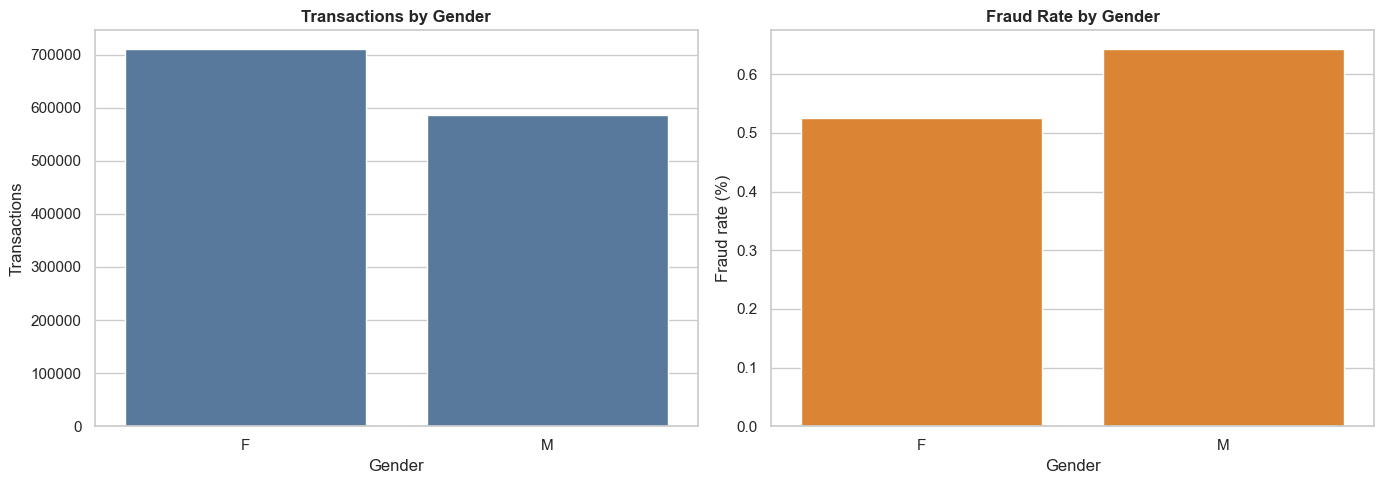

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=gender_stats, x="gender", y="transactions", ax=axes[0], color="#4C78A8")
axes[0].set_title("Transactions by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Transactions")
axes[0].ticklabel_format(style="plain", axis="y")

sns.barplot(data=gender_stats, x="gender", y="fraud_rate_percent", ax=axes[1], color="#F58518")
axes[1].set_title("Fraud Rate by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Fraud rate (%)")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "gender_transactions_and_fraud_rate.png", dpi=160, bbox_inches="tight")
plt.show()

In [24]:
eda_df["customer_age"] = ((eda_df["trans_date_trans_time"] - eda_df["dob"]).dt.days / 365.25).astype(int)
age_bins = [0, 18, 25, 35, 45, 55, 65, 120]
age_labels = ["<18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
eda_df["age_group"] = pd.cut(eda_df["customer_age"], bins=age_bins, labels=age_labels, right=False)

age_stats = (
    eda_df.groupby("age_group", observed=True)
    .agg(transactions=("is_fraud", "size"), fraud_count=("is_fraud", "sum"), fraud_rate=("is_fraud", "mean"), avg_amount=("amt", "mean"))
    .assign(fraud_rate_percent=lambda x: x["fraud_rate"] * 100)
    .reset_index()
)
age_stats

,age_group,transactions,fraud_count,fraud_rate,avg_amount,fraud_rate_percent
0,<18,15568,118,0.0076,66.0112,0.7580
1,18-24,106120,646,0.0061,61.2410,0.6087
2,25-34,287749,1391,0.0048,74.5960,0.4834
3,35-44,272940,1163,0.0043,75.7846,0.4261
4,45-54,256553,1491,0.0058,68.9856,0.5812
5,55-64,164087,1259,0.0077,66.5005,0.7673
6,65+,193658,1438,0.0074,66.7980,0.7425


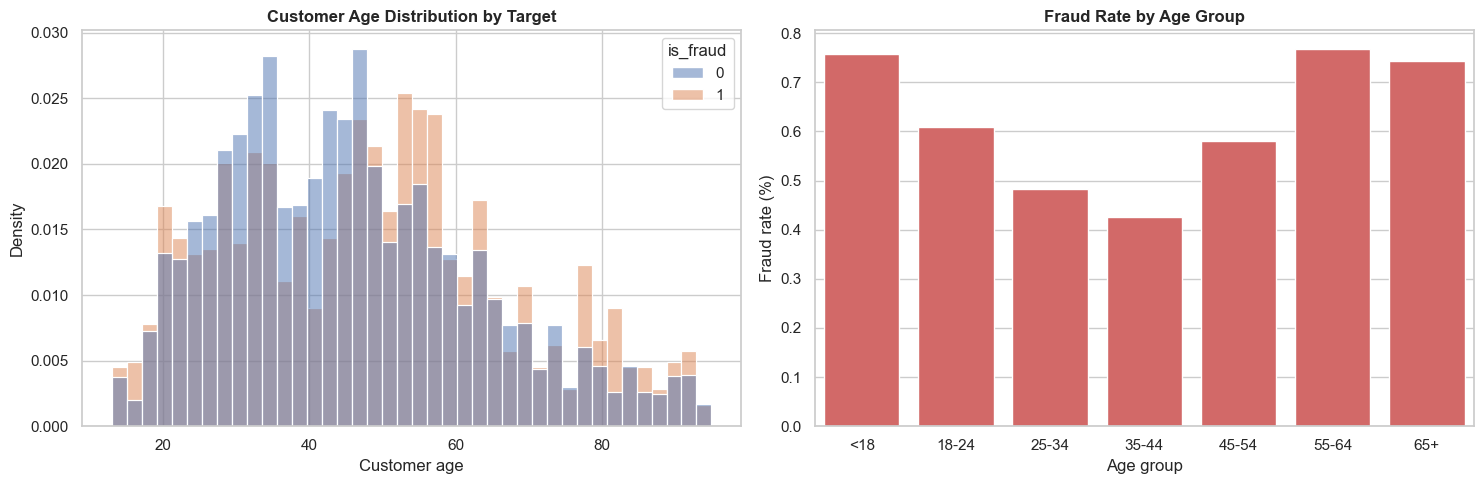

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=eda_df.sample(n=min(200_000, len(eda_df)), random_state=42), x="customer_age", hue="is_fraud", bins=40, stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Customer Age Distribution by Target")
axes[0].set_xlabel("Customer age")
axes[0].set_ylabel("Density")

sns.barplot(data=age_stats, x="age_group", y="fraud_rate_percent", ax=axes[1], color="#E45756")
axes[1].set_title("Fraud Rate by Age Group")
axes[1].set_xlabel("Age group")
axes[1].set_ylabel("Fraud rate (%)")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "age_distribution_and_fraud_rate.png", dpi=160, bbox_inches="tight")
plt.show()

In [26]:
state_stats = (
    eda_df.groupby("state")
    .agg(transactions=("is_fraud", "size"), fraud_count=("is_fraud", "sum"), fraud_rate=("is_fraud", "mean"), avg_amount=("amt", "mean"))
    .assign(fraud_rate_percent=lambda x: x["fraud_rate"] * 100)
    .sort_values("transactions", ascending=False)
    .reset_index()
)
state_stats.to_csv(TABLE_DIR / "state_fraud_stats.csv", index=False)
state_stats.head(15)

,state,transactions,fraud_count,fraud_rate,avg_amount,fraud_rate_percent
0,TX,94876,479,0.0050,71.6822,0.5049
1,NY,83501,555,0.0066,71.9333,0.6647
2,PA,79847,458,0.0057,72.2758,0.5736
3,CA,56360,326,0.0058,73.4223,0.5784
4,OH,46480,321,0.0069,73.0668,0.6906
5,MI,46154,238,0.0052,71.1255,0.5157
6,IL,43252,248,0.0057,69.6359,0.5734
7,FL,42671,281,0.0066,73.9423,0.6585
8,AL,40989,215,0.0052,65.4497,0.5245
9,MO,38403,191,0.0050,68.6783,0.4974


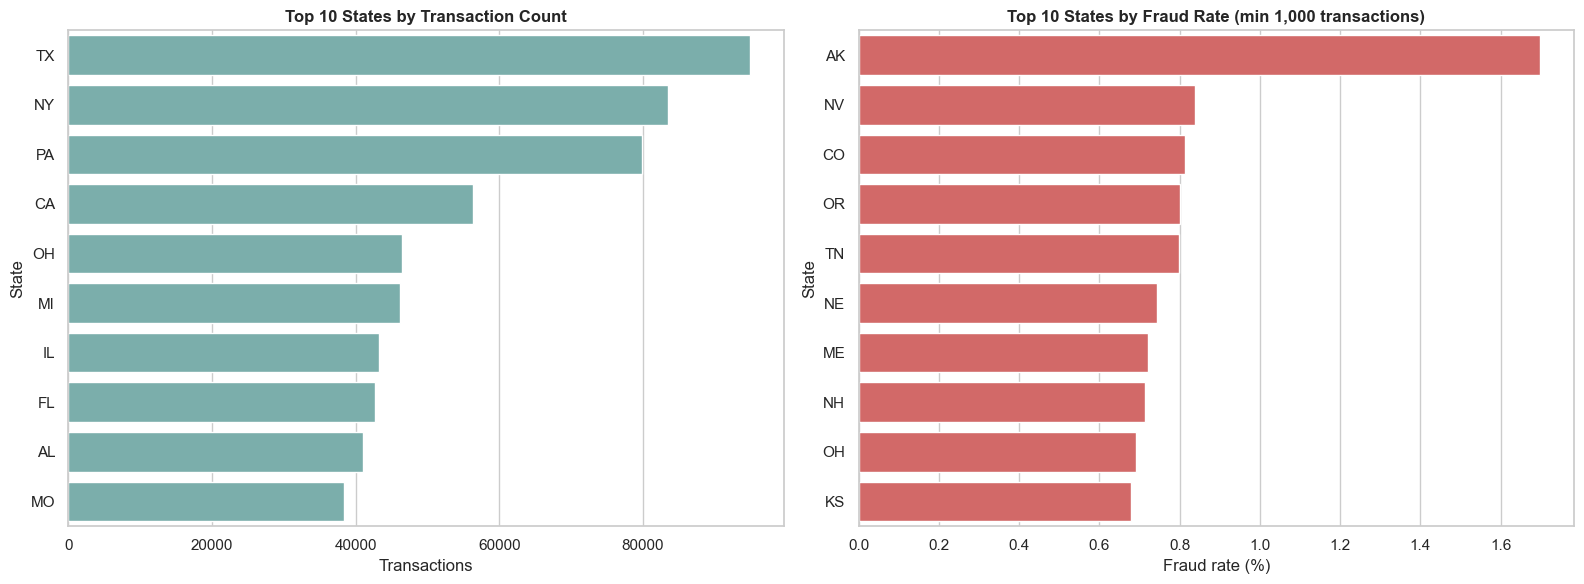

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_states = state_stats.sort_values("transactions", ascending=False).head(10)
sns.barplot(data=top_states, y="state", x="transactions", ax=axes[0], color="#72B7B2")
axes[0].set_title("Top 10 States by Transaction Count")
axes[0].set_xlabel("Transactions")
axes[0].set_ylabel("State")

high_rate_states = state_stats.query("transactions >= 1000").sort_values("fraud_rate_percent", ascending=False).head(10)
sns.barplot(data=high_rate_states, y="state", x="fraud_rate_percent", ax=axes[1], color="#E45756")
axes[1].set_title("Top 10 States by Fraud Rate (min 1,000 transactions)")
axes[1].set_xlabel("Fraud rate (%)")
axes[1].set_ylabel("State")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "state_transaction_count_and_fraud_rate.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Geographic Distance Feature

Dữ liệu có tọa độ khách hàng (`lat`, `long`) và tọa độ merchant (`merch_lat`, `merch_long`). Khoảng cách giữa 2 điểm có thể là feature hữu ích.


In [28]:
def haversine_distance_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(a))

eda_df["customer_merchant_distance_km"] = haversine_distance_km(
    eda_df["lat"], eda_df["long"], eda_df["merch_lat"], eda_df["merch_long"]
)

eda_df.groupby("is_fraud")["customer_merchant_distance_km"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,"1,289,169.0000",76.1138,29.1191,0.0223,55.3327,78.2330,98.5045,152.1172
1,"7,506.0000",76.2683,28.7526,0.7388,55.6329,77.9320,98.3911,144.5224


In [29]:
distance_bins = [0, 10, 25, 50, 75, 100, 150, 250]
eda_df["distance_group"] = pd.cut(eda_df["customer_merchant_distance_km"], bins=distance_bins, include_lowest=True)

distance_stats = (
    eda_df.groupby("distance_group", observed=True)
    .agg(transactions=("is_fraud", "size"), fraud_count=("is_fraud", "sum"), fraud_rate=("is_fraud", "mean"))
    .assign(fraud_rate_percent=lambda x: x["fraud_rate"] * 100)
    .reset_index()
)
distance_stats

,distance_group,transactions,fraud_count,fraud_rate,fraud_rate_percent
0,"(-0.001, 10.0]",10566,53,0.0050,0.5016
1,"(10.0, 25.0]",55635,302,0.0054,0.5428
2,"(25.0, 50.0]",198995,1128,0.0057,0.5668
3,"(50.0, 75.0]",331069,1989,0.0060,0.6008
4,"(75.0, 100.0]",397559,2287,0.0058,0.5753
5,"(100.0, 150.0]",302849,1747,0.0058,0.5769
6,"(150.0, 250.0]",2,0,0.0000,0.0000


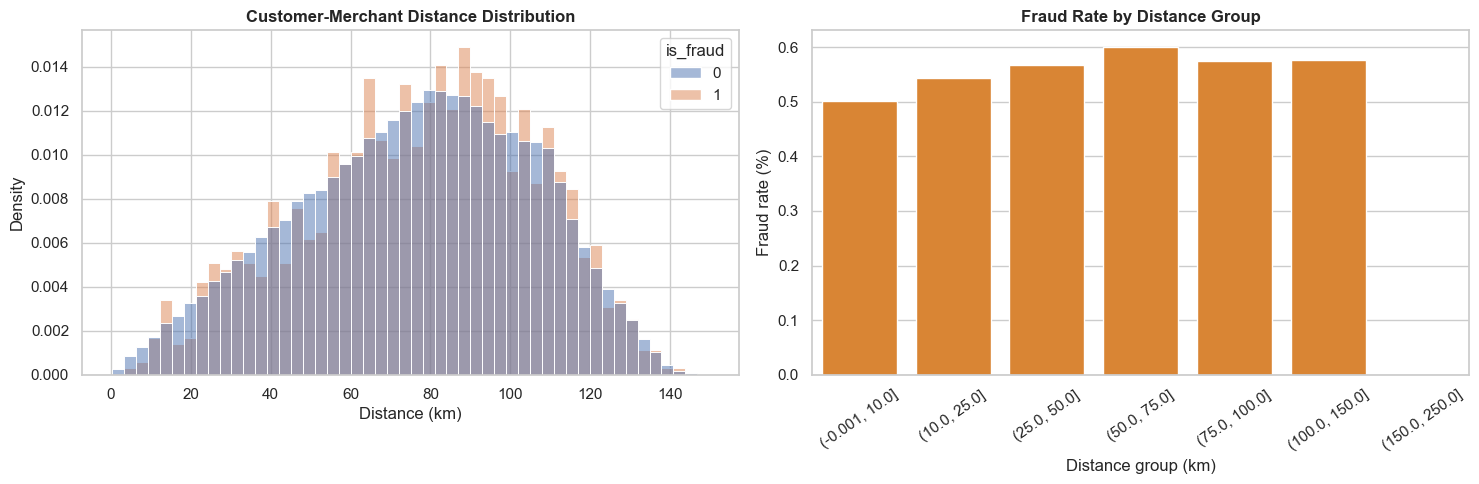

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=eda_df.sample(n=min(200_000, len(eda_df)), random_state=42),
    x="customer_merchant_distance_km",
    hue="is_fraud",
    bins=50,
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Customer-Merchant Distance Distribution")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Density")

plot_distance = distance_stats.copy()
plot_distance["distance_group"] = plot_distance["distance_group"].astype(str)
sns.barplot(data=plot_distance, x="distance_group", y="fraud_rate_percent", ax=axes[1], color="#F58518")
axes[1].set_title("Fraud Rate by Distance Group")
axes[1].set_xlabel("Distance group (km)")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "distance_distribution_and_fraud_rate.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Correlation Check

Kiểm tra tương quan tuyến tính giữa các biến số và target. Tương quan thấp không có nghĩa feature vô dụng vì fraud detection thường có quan hệ phi tuyến.


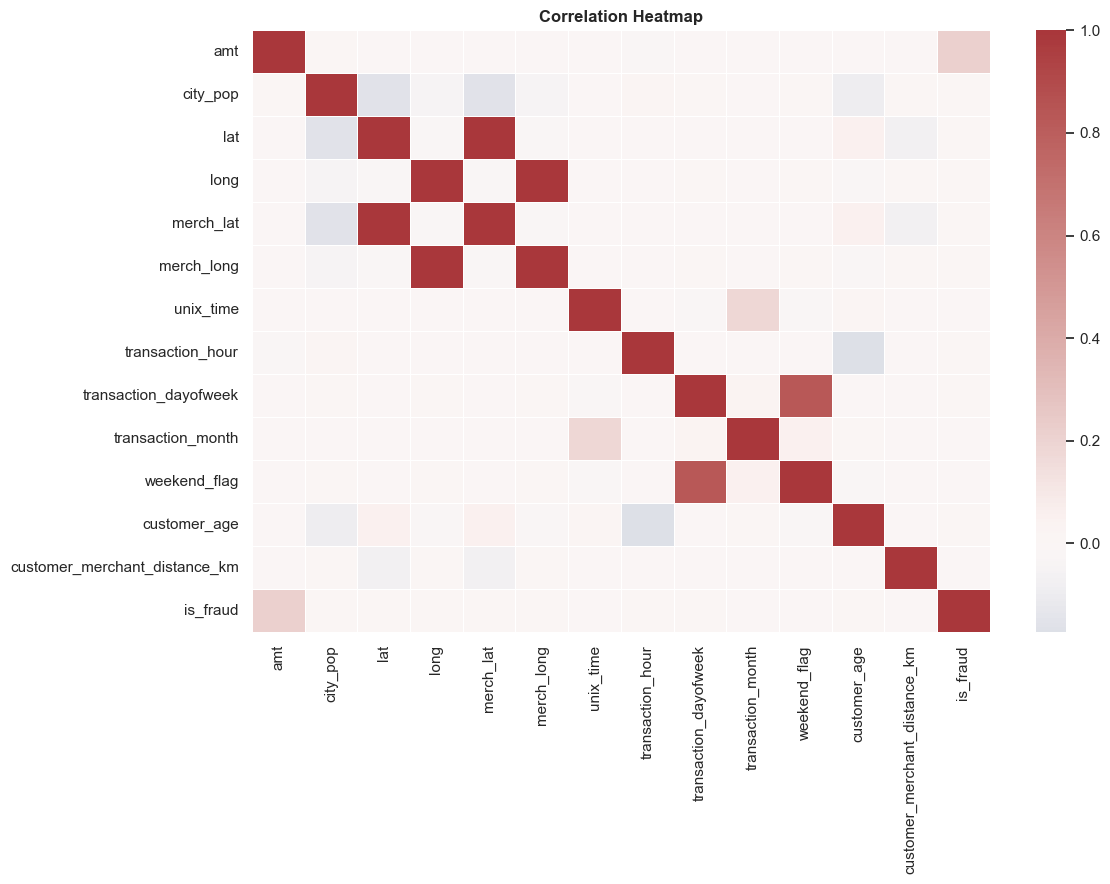

In [31]:
correlation_cols = [
    "amt", "city_pop", "lat", "long", "merch_lat", "merch_long",
    "unix_time", "transaction_hour", "transaction_dayofweek", "transaction_month",
    "weekend_flag", "customer_age", "customer_merchant_distance_km", "is_fraud",
]

corr = eda_df[correlation_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

In [32]:
target_corr = (
    corr["is_fraud"]
    .drop("is_fraud")
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", "is_fraud": "correlation_with_is_fraud"})
)
target_corr.to_csv(TABLE_DIR / "numeric_correlation_with_target.csv", index=False)
target_corr

,feature,correlation_with_is_fraud
0,amt,0.2194
1,transaction_hour,0.0138
2,transaction_month,-0.0124
3,customer_age,0.0123
4,unix_time,-0.0051
5,weekend_flag,-0.0036
6,city_pop,0.0021
7,lat,0.0019
8,merch_lat,0.0017
9,transaction_dayofweek,0.0017


## 13. EDA Summary and Next Steps

### Nhận xét chính

- Dataset có quy mô lớn: hơn 1.29 triệu dòng train và hơn 555 nghìn dòng test.
- Target `is_fraud` bị mất cân bằng rất mạnh, fraud chỉ chiếm dưới 1% tổng giao dịch.
- `amt`, `category`, `merchant`, thời gian giao dịch, state, age và khoảng cách customer-merchant đều là nhóm feature đáng xem xét cho modeling.
- Các cột định danh trực tiếp như `first`, `last`, `street`, `trans_num`, `cc_num` nên được xử lý cẩn thận hoặc loại bỏ trong preprocessing.
- Với merchant/job/category có nhiều giá trị phân loại, cần chọn encoding phù hợp để tránh bùng nổ chiều dữ liệu.

### Feature gợi ý cho preprocessing

- `transaction_hour`, `transaction_dayofweek`, `transaction_month`, `weekend_flag`
- `customer_age`
- `customer_merchant_distance_km`
- Encoded categorical variables: `category`, `gender`, `state`, có thể thêm `job` và `merchant` nếu xử lý cardinality tốt
- Scaled numeric variables: `amt`, `city_pop`, `customer_age`, `customer_merchant_distance_km`

### Lưu ý khi modeling

- Không nên chỉ báo cáo Accuracy vì dữ liệu mất cân bằng.
- Nên dùng Precision, Recall, F1-score, ROC-AUC và confusion matrix.
- Với Logistic Regression/Random Forest, nên dùng `class_weight="balanced"` hoặc kỹ thuật sampling phù hợp.
